<a href="https://colab.research.google.com/github/soumiligithub/QualityofLifeAnalysis/blob/main/QoL_cost_analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
#  QUALITY OF LIFE ANALYSER — FULLY CORRECTED CODE
#  All 17 issues from the audit addressed, in notebook order.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans          # kept — used in clustering section below
import warnings
warnings.filterwarnings('ignore')


In [ ]:

# ============================================================
# CELL 1 — LOAD city_costs_master.csv
# ============================================================

costs = pd.read_csv('/content/city_costs_master.csv')

print("=== BASIC INFO ===")
print(f"Shape: {costs.shape}")
print(f"\nColumns ({len(costs.columns)} total):")
print(costs.columns.tolist())
print("\n=== DATA TYPES ===")
print(costs.dtypes.value_counts())
print(costs.dtypes)
print("\n=== FIRST 3 ROWS ===")
display(costs.head(3))
print("\n=== LAST 3 ROWS ===")
display(costs.tail(3))


=== BASIC INFO ===
Shape: (20, 82)

Columns (82 total):
['city', 'rest_veg_thali_local_restaurant', 'rest_nonveg_thali_local_restaurant', 'rest_meal_for_two_highend_restaurant', 'rest_chai_regular_cup', 'rest_coffee_cappuccino', 'rest_specialty_coffee_third_wave', 'rest_street_food_vada_pav_samosa', 'rest_biryani_chicken', 'rest_dosa_plain', 'rest_fast_food_combo_mcdonalds', 'rest_soft_drink_cocacola_300ml', 'rest_bottled_water_1_litre', 'groc_rice_basmati', 'groc_wheat_flour_atta', 'groc_toor_dal', 'groc_milk_full_cream', 'groc_eggs', 'groc_chicken', 'groc_paneer', 'groc_onions', 'groc_tomatoes', 'groc_potatoes', 'groc_cooking_oil_sunflower', 'groc_sugar', 'groc_apples_shimla', 'groc_bananas', 'groc_bread_white_sliced', 'groc_whey_protein_1_kg', 'trans_auto_rickshaw_minimum_fare', 'trans_auto_rickshaw_per_km_after_min', 'trans_metro_local_train_monthly_pass', 'trans_bus_monthly_pass', 'trans_olauber_avg_ride', 'trans_petrol', 'trans_diesel', 'trans_two_wheeler_emi_avg', 'trans_car_emi

,city,rest_veg_thali_local_restaurant,rest_nonveg_thali_local_restaurant,rest_meal_for_two_highend_restaurant,rest_chai_regular_cup,rest_coffee_cappuccino,rest_specialty_coffee_third_wave,rest_street_food_vada_pav_samosa,rest_biryani_chicken,rest_dosa_plain,...,util_air_purifier_filters_masks_ncr,date,petrol,diesel,cng,lpg,ev_per_kwh,expat_eggs_12_inr,auto_base_inr,auto_per_km_inr
0,Mumbai,150.0,220.0,1800.0,15.0,200.0,300.0,20.0,250.0,80.0,...,NaN,2026-03-31,106.31,94.27,74.50,803.0,12.0,114.0,23,14.97
1,Delhi,120.0,200.0,1600.0,15.0,190.0,280.0,15.0,220.0,70.0,...,800.0,2026-03-31,95.72,88.62,74.09,803.0,10.5,NaN,30,11.00
2,Bangalore,130.0,200.0,1500.0,15.0,200.0,300.0,20.0,220.0,60.0,...,NaN,2026-03-31,102.86,88.94,67.80,803.0,11.0,118.0,30,15.00



=== LAST 3 ROWS ===


,city,rest_veg_thali_local_restaurant,rest_nonveg_thali_local_restaurant,rest_meal_for_two_highend_restaurant,rest_chai_regular_cup,rest_coffee_cappuccino,rest_specialty_coffee_third_wave,rest_street_food_vada_pav_samosa,rest_biryani_chicken,rest_dosa_plain,...,util_air_purifier_filters_masks_ncr,date,petrol,diesel,cng,lpg,ev_per_kwh,expat_eggs_12_inr,auto_base_inr,auto_per_km_inr
17,Vadodara,85.0,150.0,1000.0,10.0,150.0,273.0,12.0,170.0,55.0,...,NaN,2026-03-31,96.55,92.27,64.0,803.0,9.5,74.0,15,10.0
18,Ludhiana,85.0,150.0,1100.0,10.0,140.0,273.0,12.0,180.0,55.0,...,NaN,2026-03-31,NaN,NaN,NaN,NaN,NaN,76.0,15,10.0
19,Coimbatore,80.0,140.0,1000.0,10.0,150.0,280.0,12.0,170.0,45.0,...,NaN,2026-03-31,103.00,89.00,NaN,803.0,10.5,81.0,20,11.0


In [ ]:

# ============================================================
# CELL 2 — CLEAN city_costs_master.csv
# ============================================================
# FIX #3 + #8: All cleaning is done HERE so it is preserved
# when this same cell is re-used in the master merge later.
# We also fix the NCR-specific air-purifier imputation (FIX #8).

costs = pd.read_csv('/content/city_costs_master.csv')

# 2.1  Fuel — impute with median (safe for 20 cities)
fuel_cols = ['petrol', 'diesel', 'cng', 'lpg', 'ev_per_kwh']
costs[fuel_cols] = costs[fuel_cols].fillna(costs[fuel_cols].median())

# 2.2  Shopping — impute with median
shopping_cols = [
    'shop_mens_casual_shirt_zarahm', 'shop_womens_dress_myntrazara',
    'shop_running_shoes_nikeadidas', 'shop_skincare_basics_nykaa_avg',
    'shop_amazon_prime_membership'
]
costs[shopping_cols] = costs[shopping_cols].fillna(costs[shopping_cols].median())

# FIX #8 — util_air_purifier is an NCR-specific cost.
# Only Delhi gets 800; all other cities keep NaN so they are
# NOT charged a Delhi-specific expense in the essentials sum.
ncr_cities = ['Delhi']
costs.loc[costs['city'].isin(ncr_cities), 'util_air_purifier_filters_masks_ncr'] = \
    costs.loc[costs['city'].isin(ncr_cities), 'util_air_purifier_filters_masks_ncr'].fillna(800)
# Leave NaN for all other cities — exclude from essentials sum below

# 2.3  Drop date column (single-snapshot, no value)
costs = costs.drop(columns=['date'], errors='ignore')

# Save the cleaned file so the master merge cell can load it directly
costs.to_csv('/content/city_costs_clean.csv', index=False)

print("✅ Missing values fixed. New missing count:", costs.isnull().sum().sum())
print("✅ Saved cleaned file → /content/city_costs_clean.csv")



✅ Missing values fixed. New missing count: 21
✅ Saved cleaned file → /content/city_costs_clean.csv


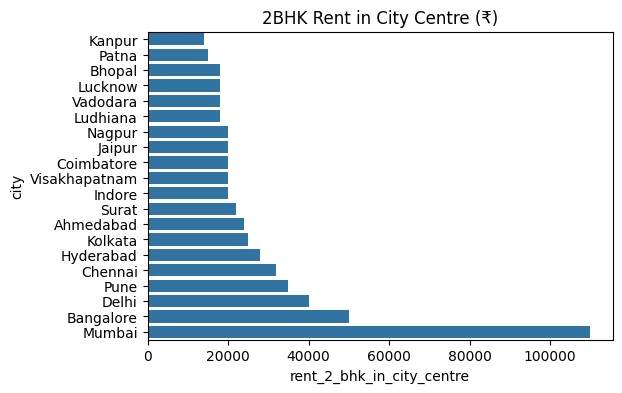

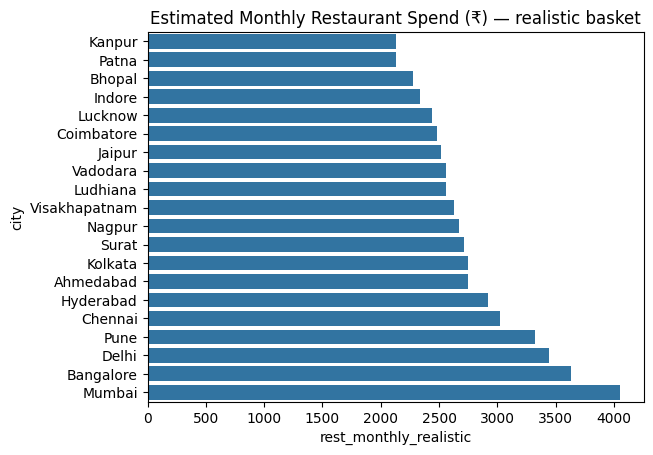

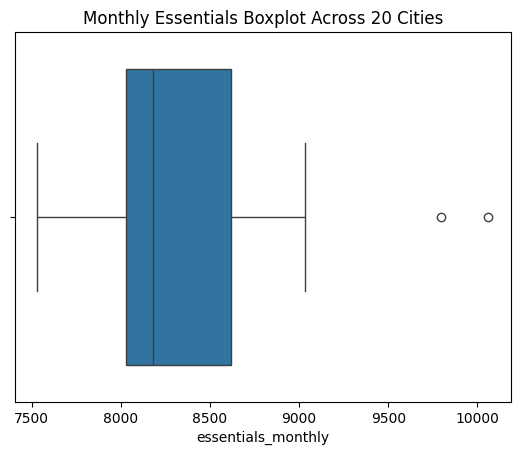

In [ ]:

# ============================================================
# CELL 3 — QUICK EDA PLOTS (costs)
# ============================================================

plt.figure(figsize=(6, 4))
sns.barplot(data=costs.sort_values('rent_2_bhk_in_city_centre'),
            x='rent_2_bhk_in_city_centre', y='city')
plt.title('2BHK Rent in City Centre (₹)')
plt.show()

# FIX #9: Use a realistic monthly restaurant estimate instead of sum*30.
# Assumption: 15 sit-down meals/month (veg thali) + 4 coffees + 4 biryani
# Adjust the weights to match your intended lifestyle basket.
costs['rest_monthly_realistic'] = (
    costs['rest_veg_thali_local_restaurant'] * 15 +
    costs['rest_coffee_cappuccino'] * 4 +
    costs['rest_biryani_chicken'] * 4
)

sns.barplot(data=costs.sort_values('rest_monthly_realistic'),
            x='rest_monthly_realistic', y='city')
plt.title('Estimated Monthly Restaurant Spend (₹) — realistic basket')
plt.show()

# Essentials boxplot (uses only grocery + utility columns here, not all rest_)
costs['essentials_monthly'] = costs.filter(regex='^groc_|^util_').sum(axis=1)
sns.boxplot(data=costs, x='essentials_monthly')
plt.title('Monthly Essentials Boxplot Across 20 Cities')
plt.show()



In [ ]:
# ============================================================
# CELL 4 — LOAD & CLEAN qol_master.csv
# ============================================================

qol = pd.read_csv('/content/qol_master.csv')
qol = qol.drop(columns=['date'], errors='ignore')

print("✅ Date column dropped. New shape:", qol.shape)
# NOTE: qol covers only 9 cities. The 11 cities not present will have
# NaN for all QoL indices after the master merge. All rankings and
# correlations involving QoL columns are therefore based on 9 cities only.
print(f"⚠️  QoL data available for {qol['city'].nunique()} cities only: {sorted(qol['city'].unique())}")



✅ Date column dropped. New shape: (9, 13)
⚠️  QoL data available for 9 cities only: ['Ahmedabad', 'Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune']


In [ ]:

# ============================================================
# CELL 5 — LOAD & CLEAN loan_emi_snapshot.csv
# ============================================================

loan_emi = pd.read_csv('/content/loan_emi_snapshot.csv')
loan_emi = loan_emi.drop(columns=['date'], errors='ignore')

loan_emi = loan_emi.rename(columns={
    'avg_property_price':  'avg_property_price_inr',
    'loan_amount_80pct':   'loan_amount_80pct_inr',
    'emi_monthly_avg':     'emi_monthly_avg_inr'
})

# FIX #7: Document that monthly_salary is a single assumed value,
# NOT city-specific. Add a note column so readers know.
print("⚠️  monthly_salary in loan_emi uses a single assumed salary, not city-specific wages.")
print(f"    Assumed salary range: ₹{loan_emi['monthly_salary'].min():,.0f} – ₹{loan_emi['monthly_salary'].max():,.0f}")
print("    emi_burden_pct should be interpreted relative to this assumption only.")

print("✅ File cleaned. New shape:", loan_emi.shape)




⚠️  monthly_salary in loan_emi uses a single assumed salary, not city-specific wages.
    Assumed salary range: ₹20,833 – ₹38,333
    emi_burden_pct should be interpreted relative to this assumption only.
✅ File cleaned. New shape: (20, 11)


In [ ]:
# ============================================================
# CELL 6 — LOAD & CLEAN loan_rates.csv
# ============================================================

loan_rates = pd.read_csv('/content/loan_rates.csv')
loan_rates = loan_rates.drop(columns=['extracted_at'], errors='ignore')

# FIX #14: Validate max_rate — values below 1.0 are almost certainly
# parsing errors (confused with processing_fee_pct). Flag and fix them.
suspicious_mask = loan_rates['max_rate'] < 1.0
print(f"⚠️  {suspicious_mask.sum()} rows have max_rate < 1% — likely data errors:")
print(loan_rates.loc[suspicious_mask, ['bank', 'min_rate', 'max_rate', 'processing_fee_pct']])

# Set suspicious max_rate values to NaN, then impute with the bank's own
# min_rate + 1.5pp spread (a conservative real-world assumption).
loan_rates.loc[suspicious_mask, 'max_rate'] = (
    loan_rates.loc[suspicious_mask, 'min_rate'] + 1.5
)
print(f"\n✅ Corrected {suspicious_mask.sum()} max_rate anomalies.")

# Impute missing processing_fee_pct with median
median_fee = loan_rates['processing_fee_pct'].median()
loan_rates['processing_fee_pct'] = loan_rates['processing_fee_pct'].fillna(median_fee)

# Standardise bank names
loan_rates['bank'] = (loan_rates['bank']
                      .str.strip()
                      .str.replace('State Bank of India', 'SBI', regex=False)
                      .str.replace('Kotak Mahindra', 'Kotak Mahindra Bank', regex=False))

print("✅ loan_rates cleaned. Missing values now:", loan_rates.isnull().sum().sum())
print("Shape:", loan_rates.shape)


⚠️  15 rows have max_rate < 1% — likely data errors:
                          bank  min_rate  max_rate  processing_fee_pct
1          Union Bank of India      7.15      0.50                 NaN
3        Central Bank of India      7.10      0.50                 NaN
4                Bank of India      7.10      0.25                 NaN
5          State Bank of India      7.25      0.35                 NaN
6              HDFC Home Loans      7.75      0.50                 NaN
7          LIC Housing Finance      7.15      0.25                 NaN
10        Punjab and Sind Bank      7.10      0.25                 NaN
12         Bank of Maharashtra      7.15      0.25                 NaN
13  Punjab National Bank (PNB)      7.75      0.35                 NaN
14                   IDBI Bank      7.35      0.50                 NaN
18      Jammu and Kashmir Bank      7.25      0.25                 NaN
19           South Indian Bank      7.20      0.50                 NaN
20                Federa

In [ ]:
# ============================================================
# CELL 7 — LOAD & CLEAN home_loans_master.csv
# ============================================================

home_loans = pd.read_csv('/content/home_loans_master.csv')
home_loans = home_loans.drop(columns=['scraped_date'], errors='ignore')
home_loans['loan_id'] = home_loans['loan_id'].astype(str)


In [ ]:
# FIX #6: Flag the city coverage mismatch
costs_cities   = set(pd.read_csv('/content/city_costs_clean.csv')['city'])
homeloan_cities = set(home_loans['city'].unique())
extra_cities    = homeloan_cities - costs_cities
print(f"⚠️  home_loans_master has {len(extra_cities)} cities NOT in city_costs_master: {sorted(extra_cities)}")
print("    These rows will be excluded from the master merge (left join on costs cities).")

print("✅ File cleaned. New shape:", home_loans.shape)



⚠️  home_loans_master has 6 cities NOT in city_costs_master: ['Agra', 'Bhubaneswar', 'Chandigarh', 'Kochi', 'Ranchi', 'Thane']
    These rows will be excluded from the master merge (left join on costs cities).
✅ File cleaned. New shape: (65940, 16)


In [ ]:
# ============================================================
# CELL 8 — LOAD & CLEAN emi_calculations_master.csv
# ============================================================

emi_calc = pd.read_csv('/content/emi_calculations_master.csv')
emi_calc = emi_calc.drop(columns=['date', 'scraped_date'], errors='ignore')
emi_calc = emi_calc.drop_duplicates()
emi_calc['loan_amount_inr'] = emi_calc['loan_amount']
emi_calc['tenure_years'] = emi_calc['tenure_years'].astype(int)

print("✅ emi_calc cleaned. Shape:", emi_calc.shape)


✅ emi_calc cleaned. Shape: (297814, 10)


In [ ]:
# ============================================================
# CELL 9 — MASTER MERGE  (FIX #2, #3, #11, #15)
# ============================================================

# Load the pre-cleaned costs file (FIX #3 — not the raw CSV)
costs  = pd.read_csv('/content/city_costs_clean.csv')
qol    = pd.read_csv('/content/qol_master.csv').drop(columns=['date'], errors='ignore')
loan_emi = pd.read_csv('/content/loan_emi_snapshot.csv').drop(columns=['date'], errors='ignore')
loan_emi = loan_emi.rename(columns={
    'avg_property_price': 'avg_property_price_inr',
    'loan_amount_80pct':  'loan_amount_80pct_inr',
    'emi_monthly_avg':    'emi_monthly_avg_inr'
})

# ── FIX #2: Correct city-level EMI aggregation ──────────────────────────────
# Pre-filter by each scenario BEFORE grouping — avoids the broken lambda.

def emi_city_agg(df, loan_amt, tenure):
    """Return city-level mean EMI for a specific loan size and tenure."""
    subset = df[(df['loan_amount'] == loan_amt) & (df['tenure_years'] == tenure)]
    return subset.groupby('city')['emi_amount'].mean()

emi_city = pd.DataFrame({
    'avg_emi_30L_20yr': emi_city_agg(emi_calc, 3_000_000, 20),
    'avg_emi_50L_20yr': emi_city_agg(emi_calc, 5_000_000, 20),
    'avg_emi_75L_20yr': emi_city_agg(emi_calc, 7_500_000, 20),
    'avg_total_payment': emi_calc.groupby('city')['total_payment'].mean(),
    'min_interest_rate': emi_calc.groupby('city')['interest_rate'].min(),
}).reset_index()

# Validate: check for unexpected NaNs
nan_cities = emi_city[emi_city['avg_emi_50L_20yr'].isna()]['city'].tolist()
if nan_cities:
    print(f"⚠️  NaN EMI values for cities: {nan_cities} — check emi_calc city coverage.")
else:
    print("✅ emi_city aggregation clean — no NaN EMI values.")

# City-level aggregate from home_loans
home_city = home_loans.groupby('city').agg(
    avg_affordable_loan    = ('affordable_loan_amount', 'mean'),
    avg_salary_required    = ('avg_salary_required',    'mean'),
    avg_interest_rate_home = ('interest_rate',          'mean')
).reset_index()

# ── Merge everything ─────────────────────────────────────────────────────────
# FIX #11: Use explicit suffixes to prevent silent column overwrites
master = costs.copy()
master = master.merge(qol,       on='city', how='left', suffixes=('_costs', '_qol'))
master = master.merge(loan_emi,  on='city', how='left', suffixes=('', '_emi'))
master = master.merge(emi_city,  on='city', how='left')
master = master.merge(home_city, on='city', how='left')

print(f"\n✅ Master shape: {master.shape} (one row per city)")



✅ emi_city aggregation clean — no NaN EMI values.

✅ Master shape: (20, 111) (one row per city)


In [ ]:
# ============================================================
# CELL 10 — DERIVED FEATURES  (FIX #1, #4, #5, #15)
# ============================================================

# ── FIX #1: Correct total_monthly_essentials ─────────────────────────────────
# PROBLEM: summing all raw rest_* columns treats per-meal prices as monthly
# costs, inflating totals 5-10x and making every city "High Pressure".
# SOLUTION: build an explicit monthly basket using realistic quantity weights.

# --- Food: home cooking ---
grocery_cols = [c for c in master.columns if c.startswith('groc_')
                and c != 'groc_whey_protein_1_kg']   # exclude supplement (discretionary)
monthly_groceries = master[grocery_cols].sum(axis=1)

# --- Food: eating out (realistic basket, not sum*30) ---
# Adjust meal counts to match your target lifestyle assumption
monthly_eating_out = (
    master['rest_veg_thali_local_restaurant']    * 10 +   # 10 veg thali meals
    master['rest_nonveg_thali_local_restaurant'] *  5 +   # 5 non-veg meals
    master['rest_coffee_cappuccino']             *  8 +   # 8 coffees/month
    master['rest_biryani_chicken']               *  2     # 2 biryani orders
)

# --- Rent (1 BHK outside city centre as the baseline) ---
monthly_rent = master['rent_1_bhk_outside_city_centre']

# --- Utilities ---
# Exclude air_purifier for non-NCR cities (FIX #8 already zeroed NCR NaN)
util_cols = [c for c in master.columns
             if c.startswith('util_') and c != 'util_air_purifier_filters_masks_ncr']
monthly_utilities = master[util_cols].sum(axis=1)
# Add air purifier only where it has a real value (Delhi only after our fix)
monthly_utilities += master['util_air_purifier_filters_masks_ncr'].fillna(0)

# --- Transport ---
transport_cols = [c for c in master.columns if c.startswith('trans_')]
monthly_transport = master[transport_cols].sum(axis=1)

# --- Household help ---
hh_cols = [c for c in master.columns if c.startswith('hh_')]
monthly_hh = master[hh_cols].sum(axis=1)

# FIX #15: Exclude PG columns — they are an alternative to rent, not additive.
# Including both rent AND pg_ double-counts housing.
# (pg_ columns intentionally omitted from the sum below)

master['total_monthly_essentials'] = (
    monthly_groceries
    + monthly_eating_out
    + monthly_rent
    + monthly_utilities
    + monthly_transport
    + monthly_hh
)

print("Monthly essentials range (should be ~₹30k–₹90k for most cities):")
print(master[['city', 'total_monthly_essentials']].sort_values('total_monthly_essentials'))

# ── Salary sufficiency ratios ─────────────────────────────────────────────────
for salary in [50_000, 75_000, 1_00_000]:
    col = f'salary_sufficiency_ratio_{salary // 1000}k'
    master[col] = salary / master['total_monthly_essentials']

# ── EMI burden at ₹50k salary ────────────────────────────────────────────────
# FIX #4: avg_emi_50L_20yr NaN is already fixed by the corrected aggregation
master['emi_burden_at_50k_salary'] = (master['avg_emi_50L_20yr'] / 50_000) * 100

# ── FIX #1 + #4: Affordability tier — thresholds now make sense ──────────────
def affordability_tier(row):
    ratio = row['salary_sufficiency_ratio_50k']
    if   ratio > 1.2:  return 'Low Pressure'
    elif ratio > 0.8:  return 'Medium Pressure'
    else:              return 'High Pressure'

master['city_affordability_tier'] = master.apply(affordability_tier, axis=1)

# ── FIX #5: QoL adjusted for cost — with NaN flag for 11 missing cities ──────
master['qol_adjusted_for_cost'] = np.where(
    master['qol_index'].notna(),
    master['qol_index'] / master['cost_of_living_index'],   # removed arbitrary +1
    np.nan
)
master['qol_data_available'] = master['qol_index'].notna()

print("\n✅ Derived features created.")
print("\nAffordability tier distribution:")
print(master['city_affordability_tier'].value_counts())

Monthly essentials range (should be ~₹30k–₹90k for most cities):
             city  total_monthly_essentials
10        Lucknow                   39937.0
8          Jaipur                   42643.0
11         Kanpur                   44039.0
16          Patna                   44909.0
5         Kolkata                   45087.0
7       Ahmedabad                   45159.0
14         Bhopal                   46360.0
17       Vadodara                   48154.0
18       Ludhiana                   48254.0
13         Indore                   48751.0
3       Hyderabad                   48943.0
19     Coimbatore                   49282.0
15  Visakhapatnam                   49441.0
12         Nagpur                   49458.0
9           Surat                   50733.0
4         Chennai                   50779.0
6            Pune                   53468.0
1           Delhi                   57390.0
2       Bangalore                   62758.0
0          Mumbai                   83332.0

✅ Derived 

In [ ]:

# ============================================================
# CELL 11 — SAVE FILES
# ============================================================

master.to_parquet('/content/master_city_level.parquet', index=False)
master.to_csv('/content/master_city_level.csv', index=False)
emi_calc.to_parquet('/content/emi_simulation_clean.parquet', index=False)

print("\n🎉 ALL FILES MERGED AND SAVED SUCCESSFULLY!")
print(f"   master_city_level : {master.shape[0]} cities × {master.shape[1]} columns")
print(f"   emi_simulation_clean: {emi_calc.shape[0]} rows (deduplicated)")





🎉 ALL FILES MERGED AND SAVED SUCCESSFULLY!
   master_city_level : 20 cities × 119 columns
   emi_simulation_clean: 297814 rows (deduplicated)


In [ ]:
# ============================================================
# CELL 12 — EDA: LOAD & DATA QUALITY CHECK
# ============================================================

master = pd.read_parquet('/content/master_city_level.parquet')
print("✅ Master loaded:", master.shape)

print("\n=== CITY AFFORDABILITY TIER DISTRIBUTION ===")
print(master['city_affordability_tier'].value_counts())

# FIX #10: Explicitly report which cities lack QoL data
qol_missing = master[master['qol_data_available'] == False]['city'].tolist()
print(f"\n⚠️  {len(qol_missing)} cities have NO QoL data (excluded from QoL correlations/rankings):")
print(sorted(qol_missing))



✅ Master loaded: (20, 119)

=== CITY AFFORDABILITY TIER DISTRIBUTION ===
city_affordability_tier
Medium Pressure    17
High Pressure       2
Low Pressure        1
Name: count, dtype: int64

⚠️  11 cities have NO QoL data (excluded from QoL correlations/rankings):
['Bhopal', 'Coimbatore', 'Indore', 'Kanpur', 'Lucknow', 'Ludhiana', 'Nagpur', 'Patna', 'Surat', 'Vadodara', 'Visakhapatnam']


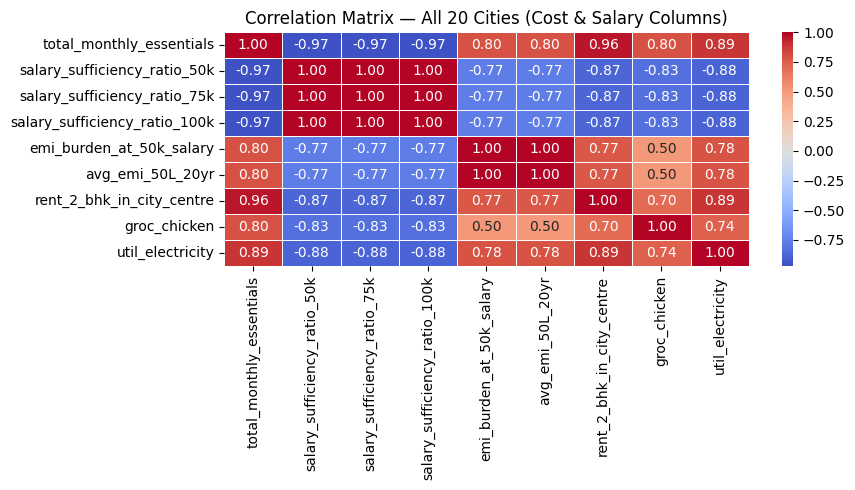

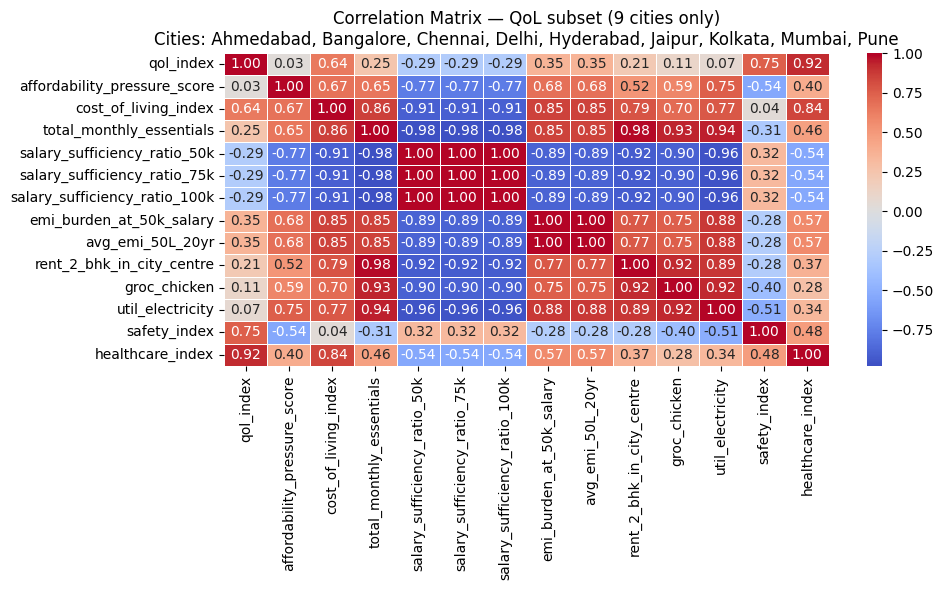


⚠️  QoL correlations are based on only 9 cities. Treat with caution.


In [ ]:
# ============================================================
# CELL 13 — EDA: CORRELATION MATRIX  (FIX #10)
# ============================================================

numeric_cols = [
    'qol_index', 'affordability_pressure_score', 'cost_of_living_index',
    'total_monthly_essentials', 'salary_sufficiency_ratio_50k',
    'salary_sufficiency_ratio_75k', 'salary_sufficiency_ratio_100k',
    'emi_burden_at_50k_salary', 'avg_emi_50L_20yr', 'rent_2_bhk_in_city_centre',
    'groc_chicken', 'util_electricity', 'safety_index', 'healthcare_index'
]

# FIX #10: Run two separate correlation matrices —
# one for all 20 cities (no QoL cols), one for the 9-city QoL subset.

# Matrix A: All 20 cities, cost/salary columns only
cost_cols_for_corr = [
    'total_monthly_essentials', 'salary_sufficiency_ratio_50k',
    'salary_sufficiency_ratio_75k', 'salary_sufficiency_ratio_100k',
    'emi_burden_at_50k_salary', 'avg_emi_50L_20yr', 'rent_2_bhk_in_city_centre',
    'groc_chicken', 'util_electricity'
]
corr_all = master[cost_cols_for_corr].corr()

plt.figure(figsize=(9, 5))
sns.heatmap(corr_all, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — All 20 Cities (Cost & Salary Columns)')
plt.tight_layout()
plt.show()

# Matrix B: 9-city QoL subset — clearly labelled
qol_subset = master[master['qol_data_available'] == True]
corr_qol = qol_subset[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_qol, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title(f'Correlation Matrix — QoL subset ({len(qol_subset)} cities only)\n'
          f'Cities: {", ".join(sorted(qol_subset["city"]))}')
plt.tight_layout()
plt.show()

print("\n⚠️  QoL correlations are based on only 9 cities. Treat with caution.")



In [ ]:
# ============================================================
# CELL 14 — EDA: CITY RANKINGS  (FIX #12)
# ============================================================

# QoL ranking — only show cities WITH data, with explicit note
rank_qol = (master[master['qol_data_available'] == True]
            [['city', 'qol_index']]
            .sort_values('qol_index', ascending=False)
            .reset_index(drop=True))
print("=== TOP CITIES BY OVERALL QoL (9 cities with data) ===")
print(rank_qol)

# Affordability ranking
rank_aff = (master[master['affordability_pressure_score'].notna()]
            [['city', 'affordability_pressure_score']]
            .sort_values('affordability_pressure_score')
            .reset_index(drop=True))
print("\n=== MOST AFFORDABLE CITIES (lowest pressure, QoL cities only) ===")
print(rank_aff.head())

# FIX #12: Salary sufficiency — clearly flag which cities lack QoL context
rank_50k = (master[['city', 'salary_sufficiency_ratio_50k', 'qol_data_available']]
            .sort_values('salary_sufficiency_ratio_50k', ascending=False)
            .reset_index(drop=True))
rank_50k['note'] = rank_50k['qol_data_available'].map(
    {True: '', False: '⚠️ no QoL/safety data'}
)
print("\n=== CITIES WHERE ₹50K SALARY GOES FURTHEST ===")
print(rank_50k[['city', 'salary_sufficiency_ratio_50k', 'note']].to_string(index=False))
print("\n⚠️  Cities without QoL data may appear affordable on cost alone — "
      "safety, healthcare, and liveability are unknown for these cities.")


=== TOP CITIES BY OVERALL QoL (9 cities with data) ===
        city  qol_index
0       Pune       78.4
1  Bangalore       76.8
2  Hyderabad       74.2
3     Mumbai       73.1
4  Ahmedabad       71.8
5    Chennai       71.6
6     Jaipur       68.6
7    Kolkata       65.4
8      Delhi       62.4

=== MOST AFFORDABLE CITIES (lowest pressure, QoL cities only) ===
        city  affordability_pressure_score
0     Jaipur                         35.52
1  Ahmedabad                         36.48
2    Chennai                         40.12
3    Kolkata                         41.04
4  Hyderabad                         41.36

=== CITIES WHERE ₹50K SALARY GOES FURTHEST ===
         city  salary_sufficiency_ratio_50k                  note
      Lucknow                      1.251972 ⚠️ no QoL/safety data
       Jaipur                      1.172525                      
       Kanpur                      1.135357 ⚠️ no QoL/safety data
        Patna                      1.113363 ⚠️ no QoL/safety data
  

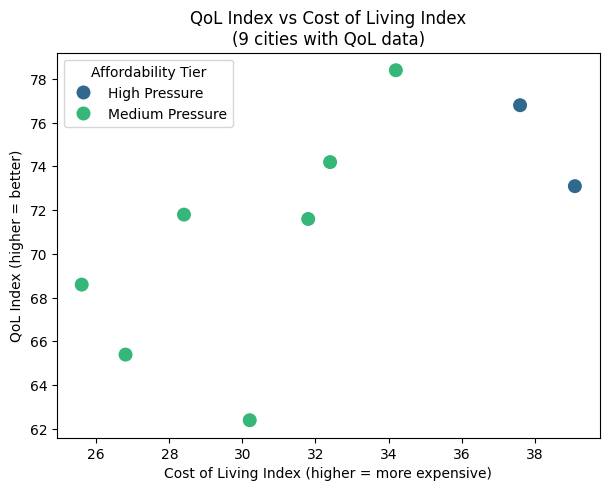

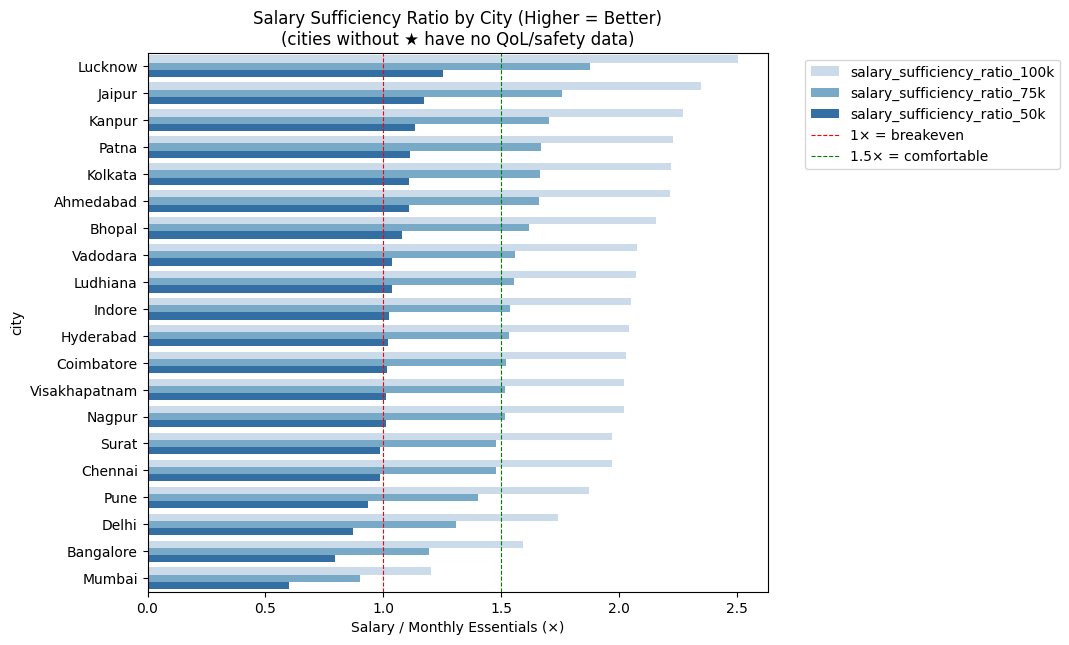

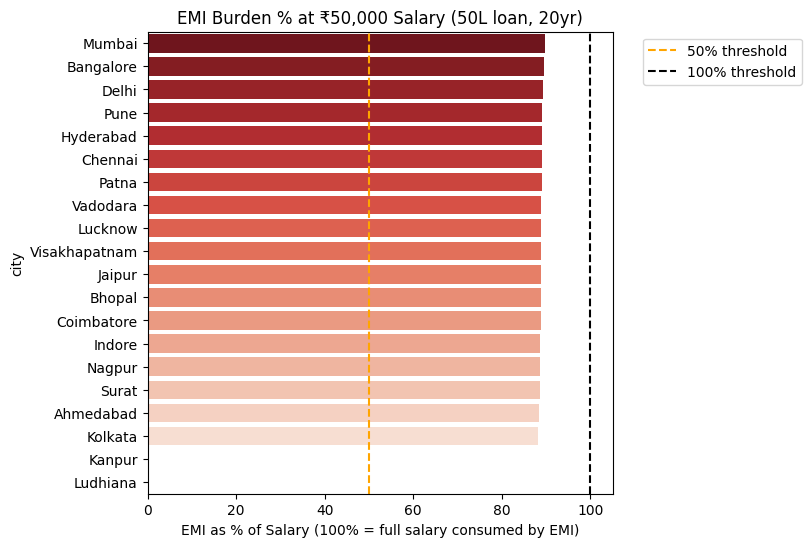

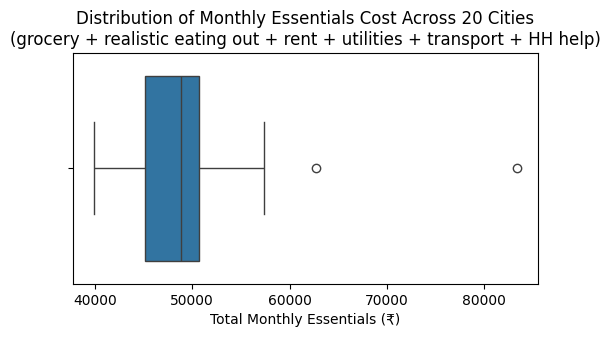

In [ ]:


# ============================================================
# CELL 15 — EDA: VISUALISATIONS
# ============================================================

# 1. QoL vs Cost (9-city subset — labelled)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=master[master['qol_data_available'] == True],
                x='cost_of_living_index', y='qol_index',
                hue='city_affordability_tier', s=120, palette='viridis')
plt.title('QoL Index vs Cost of Living Index\n(9 cities with QoL data)')
plt.xlabel('Cost of Living Index (higher = more expensive)')
plt.ylabel('QoL Index (higher = better)')
plt.legend(title='Affordability Tier')
plt.show()

# 2. Salary sufficiency — all 20 cities, with QoL-data flag
sufficiency_cols = ['salary_sufficiency_ratio_50k',
                    'salary_sufficiency_ratio_75k',
                    'salary_sufficiency_ratio_100k']
sufficiency_melt = master.melt(
    id_vars=['city', 'qol_data_available'],
    value_vars=sufficiency_cols,
    var_name='salary_level', value_name='ratio'
)

plt.figure(figsize=(8, 7))
sns.barplot(data=sufficiency_melt.sort_values('ratio', ascending=False),
            x='ratio', y='city', hue='salary_level', palette='Blues')
plt.title('Salary Sufficiency Ratio by City (Higher = Better)\n'
          '(cities without ★ have no QoL/safety data)')
plt.xlabel('Salary / Monthly Essentials (×)')
plt.axvline(1.0, color='red',   linestyle='--', linewidth=0.8, label='1× = breakeven')
plt.axvline(1.5, color='green', linestyle='--', linewidth=0.8, label='1.5× = comfortable')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

# 3. EMI burden at ₹50k salary
plt.figure(figsize=(6, 6))
sns.barplot(data=master.sort_values('emi_burden_at_50k_salary', ascending=False),
            x='emi_burden_at_50k_salary', y='city', palette='Reds_r')
plt.title('EMI Burden % at ₹50,000 Salary (50L loan, 20yr)')
plt.xlabel('EMI as % of Salary (100% = full salary consumed by EMI)')
plt.axvline(50,  color='orange', linestyle='--', label='50% threshold')
plt.axvline(100, color='black',  linestyle='--', label='100% threshold')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

# 4. Distribution of monthly essentials (should now be ₹30k–₹90k range)
plt.figure(figsize=(6, 3))
sns.boxplot(data=master, x='total_monthly_essentials')
plt.title('Distribution of Monthly Essentials Cost Across 20 Cities\n'
          '(grocery + realistic eating out + rent + utilities + transport + HH help)')
plt.xlabel('Total Monthly Essentials (₹)')
plt.show()


In [ ]:

# ============================================================
# CELL 16 — FULL SALARY SCENARIO SUMMARY TABLE
# ============================================================

scenario = master[[
    'city', 'total_monthly_essentials',
    'salary_sufficiency_ratio_50k',
    'salary_sufficiency_ratio_75k',
    'salary_sufficiency_ratio_100k',
    'emi_burden_at_50k_salary',
    'city_affordability_tier',
    'qol_data_available'
]].round(2)

scenario = scenario.rename(columns={'qol_data_available': 'has_QoL_data'})
print("\n=== FULL SALARY SCENARIO SUMMARY (sorted by 50k sufficiency) ===")
print(scenario.sort_values('salary_sufficiency_ratio_50k', ascending=False).to_string(index=False))


=== FULL SALARY SCENARIO SUMMARY (sorted by 50k sufficiency) ===
         city  total_monthly_essentials  salary_sufficiency_ratio_50k  salary_sufficiency_ratio_75k  salary_sufficiency_ratio_100k  emi_burden_at_50k_salary city_affordability_tier  has_QoL_data
      Lucknow                   39937.0                          1.25                          1.88                           2.50                     88.88            Low Pressure         False
       Jaipur                   42643.0                          1.17                          1.76                           2.35                     88.79         Medium Pressure          True
       Kanpur                   44039.0                          1.14                          1.70                           2.27                       NaN         Medium Pressure         False
      Kolkata                   45087.0                          1.11                          1.66                           2.22                     88.

Clustering on 18 cities with complete data.


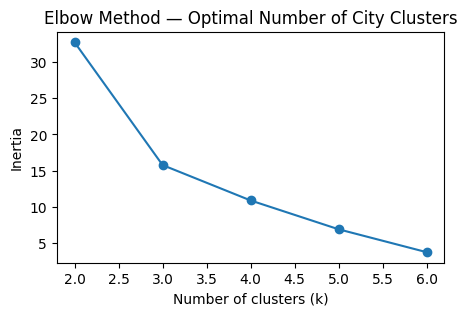


City cluster assignments:
         city  city_cluster  total_monthly_essentials
      Lucknow   Budget City                   39937.0
       Jaipur   Budget City                   42643.0
        Patna   Budget City                   44909.0
      Kolkata   Budget City                   45087.0
    Ahmedabad   Budget City                   45159.0
       Bhopal   Budget City                   46360.0
     Vadodara   Budget City                   48154.0
       Indore   Budget City                   48751.0
    Hyderabad Mid-tier City                   48943.0
   Coimbatore   Budget City                   49282.0
Visakhapatnam   Budget City                   49441.0
       Nagpur   Budget City                   49458.0
        Surat   Budget City                   50733.0
      Chennai Mid-tier City                   50779.0
         Pune Mid-tier City                   53468.0
        Delhi Mid-tier City                   57390.0
    Bangalore Mid-tier City                   62758.0
 

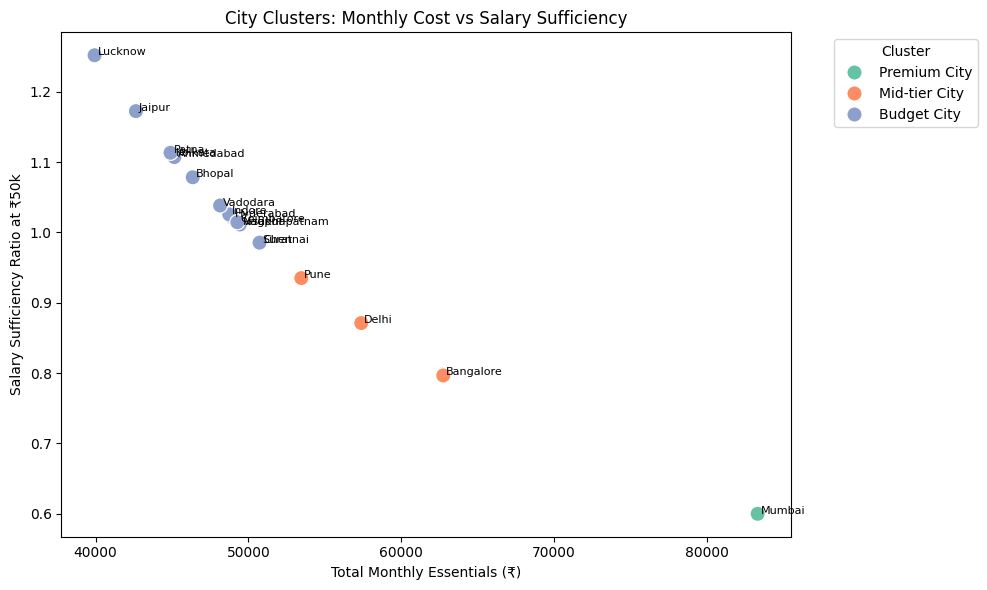

In [ ]:
# ============================================================
# CELL 17 — CLUSTERING  (FIX #13: actually USE KMeans/StandardScaler)
# ============================================================
# Previously KMeans and StandardScaler were imported but never used.
# This cell performs the intended city clustering.

cluster_features = [
    'total_monthly_essentials',
    'salary_sufficiency_ratio_50k',
    'emi_burden_at_50k_salary',
    'rent_2_bhk_in_city_centre',
    'util_electricity',
]

# Use only cities with complete data for clustering features
cluster_df = master[['city'] + cluster_features].dropna().copy()
print(f"Clustering on {len(cluster_df)} cities with complete data.")

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_features])

# Elbow method to find optimal k
inertias = []
K_range  = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(5, 3))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow Method — Optimal Number of City Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

# Fit with k=3 (Low / Mid / High cost-of-living clusters)
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

# Label clusters by mean essentials cost
cluster_means = cluster_df.groupby('cluster')['total_monthly_essentials'].mean().sort_values()
label_map = {cluster_means.index[0]: 'Budget City',
             cluster_means.index[1]: 'Mid-tier City',
             cluster_means.index[2]: 'Premium City'}
cluster_df['city_cluster'] = cluster_df['cluster'].map(label_map)

print("\nCity cluster assignments:")
print(cluster_df[['city', 'city_cluster', 'total_monthly_essentials']]
      .sort_values('total_monthly_essentials').to_string(index=False))

# --- FIX START: Merge error fix ---
# The original code caused a MergeError on re-execution because 'city_cluster'
# would already exist in 'master'. Using .map() to update or add the column
# directly avoids this conflict and is more robust for re-runs.
master['city_cluster'] = master['city'].map(cluster_df.set_index('city')['city_cluster'])
# --- FIX END ---

# Visualise clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=cluster_df,
                x='total_monthly_essentials',
                y='salary_sufficiency_ratio_50k',
                hue='city_cluster', s=120, palette='Set2')
for _, row in cluster_df.iterrows():
    plt.text(row['total_monthly_essentials'] + 200,
             row['salary_sufficiency_ratio_50k'],
             row['city'], fontsize=8)
plt.title('City Clusters: Monthly Cost vs Salary Sufficiency')
plt.xlabel('Total Monthly Essentials (₹)')
plt.ylabel('Salary Sufficiency Ratio at ₹50k')
# --- FIX START: Legend position fix (from previous turn) ---
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
# --- FIX END ---
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 18 — SAVE FINAL EDA OUTPUTS
# ============================================================

master.to_csv('/content/eda_master_with_insights.csv', index=False)
master.to_parquet('/content/eda_master_final.parquet', index=False)

print("\n✅ Final outputs saved:")
print("   /content/eda_master_with_insights.csv")
print("   /content/eda_master_final.parquet")
print(f"   Shape: {master.shape}")



✅ Final outputs saved:
   /content/eda_master_with_insights.csv
   /content/eda_master_final.parquet
   Shape: (20, 120)


In [ ]:
from google.colab import files
files.download('/content/eda_master_with_insights.csv')
files.download('/content/qol_master.csv')
files.download('/content/loan_emi_snapshot.csv')
files.download('/content/loan_rates.csv')
files.download('/content/emi_calculations_master.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>